In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [157]:
data = yf.download(
    "^NSEI",
    start="2025-01-01",
    end="2025-12-31"
)
close = data["Close"];
close.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^NSEI
Date,
2025-01-01,23742.900391
2025-01-02,24188.650391
2025-01-03,24004.750000
2025-01-06,23616.050781
2025-01-07,23707.900391


In [158]:
ln_returns = np.log(close/close.shift(1)).dropna();

ln_returns

Ticker,^NSEI
Date,
2025-01-02,0.018600
2025-01-03,-0.007632
2025-01-06,-0.016325
2025-01-07,0.003882
2025-01-08,-0.000800
...,...
2025-12-23,0.000181
2025-12-24,-0.001340
2025-12-26,-0.003825


In [159]:
log_returns = np.log(data["Close"] / data["Close"].shift(1))
# print(log_returns)
c2c_vol = log_returns.std() * np.sqrt(252)

print("C2C volatility : ",c2c_vol);

C2C volatility :  Ticker
^NSEI    0.118141
dtype: float64


In [160]:
N = len(data)

parkinson_vol = np.sqrt(
    (252 / (4 * N * np.log(2))) *
    np.sum(np.log(data["High"] / data["Low"]) ** 2)
)

print("Parkinson volatility : ",parkinson_vol)

Parkinson volatility :  0.09181856680608783


In [161]:
gk_variance = (
    0.5 * np.log(data["High"] / data["Low"])**2
    - (2 * np.log(2) - 1)
    * np.log(data["Close"] / data["Open"])**2
).mean()

gk_vol = np.sqrt(gk_variance * 252)

print("German Klass : ",gk_vol);

German Klass :  Ticker
^NSEI    0.090819
dtype: float64


In [162]:
test_data = yf.download(
    "^NSEI",
    start="2026-01-01",
    end="2026-08-01"
)

returns = ln_returns * 100


[*********************100%***********************]  1 of 1 completed


In [163]:
from arch import arch_model

model = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    o=1,
    q=1,
    power=2
)

result = model.fit()

print(result.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 1092.2930026484391
Iteration:      2,   Func. Count:     17,   Neg. LLF: 496807.18275336793
Iteration:      3,   Func. Count:     27,   Neg. LLF: 821.5593422447837
Iteration:      4,   Func. Count:     34,   Neg. LLF: 784.9236917054571
Iteration:      5,   Func. Count:     41,   Neg. LLF: 271.137358685233
Iteration:      6,   Func. Count:     48,   Neg. LLF: 257.8747488449521
Iteration:      7,   Func. Count:     55,   Neg. LLF: 261.28144326268176
Iteration:      8,   Func. Count:     62,   Neg. LLF: 255.8884846416239
Iteration:      9,   Func. Count:     69,   Neg. LLF: 255.32027120597544
Iteration:     10,   Func. Count:     76,   Neg. LLF: 254.23997654372909
Iteration:     11,   Func. Count:     82,   Neg. LLF: 254.15454424126617
Iteration:     12,   Func. Count:     88,   Neg. LLF: 254.15062825602803
Iteration:     13,   Func. Count:     94,   Neg. LLF: 254.14568682514974
Iteration:     14,   Func. Count:    100,   Neg. LLF: 254

In [164]:
horizon = len(test_data.loc["2026-01-01":"2026-08-01"])

forecast = result.forecast(horizon=horizon)

annualized_vol = (
    np.sqrt(forecast.variance.iloc[-1]) / 100
) * np.sqrt(252)

print(annualized_vol)

h.001    0.073582
h.002    0.074062
h.003    0.074537
h.004    0.075007
h.005    0.075471
           ...   
h.138    0.111880
h.139    0.112042
h.140    0.112203
h.141    0.112364
h.142    0.112523
Name: 2025-12-30 00:00:00, Length: 142, dtype: float64


In [165]:
test_log_returns = np.log(test_data["Close"] / test_data["Close"].shift(1))

test_c2c_vol = test_log_returns.rolling(window=15).std()*np.sqrt(252);

print(test_c2c_vol)


Ticker         ^NSEI
Date                
2026-01-01       NaN
2026-01-02       NaN
2026-01-05       NaN
2026-01-06       NaN
2026-01-07       NaN
...              ...
2026-07-27  0.129725
2026-07-28  0.129761
2026-07-29  0.104080
2026-07-30  0.103859
2026-07-31  0.096265

[142 rows x 1 columns]


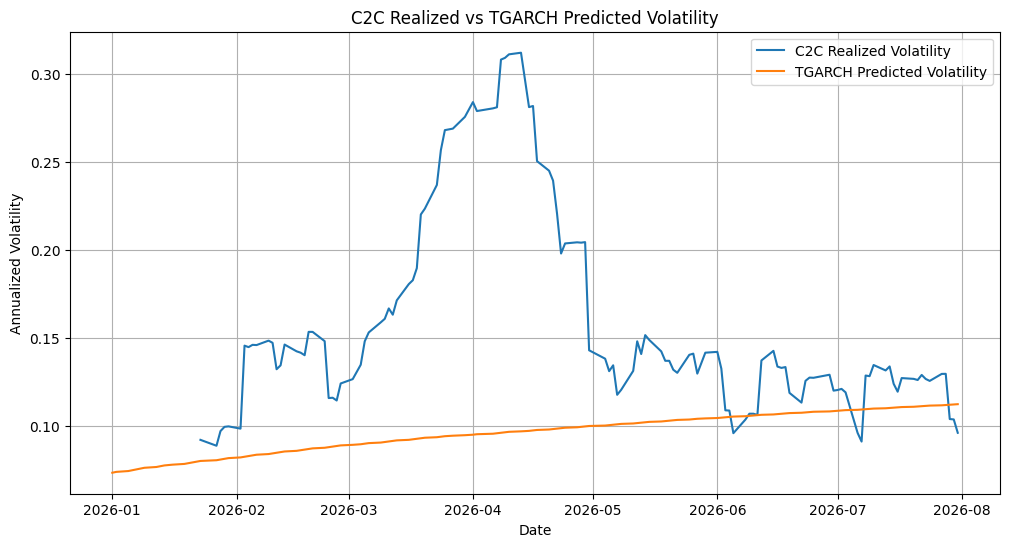

In [166]:
plt.figure(figsize=(12, 6))

plt.plot(test_data.index, test_c2c_vol, label="C2C Realized Volatility")
plt.plot(test_data.index, annualized_vol, label="TGARCH Predicted Volatility")

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("C2C Realized vs TGARCH Predicted Volatility")

plt.legend()
plt.grid(True)
plt.show()

In [167]:
predicted_vol = []

# create full return series including test period
full_data = pd.concat([data, test_data])

full_returns = np.log(
    full_data["Close"] / full_data["Close"].shift(1)
).dropna()


window = len(ln_returns)   # your 2025 training size


for i in range(len(test_data)):

    # rolling window
    train_returns = full_returns.iloc[i:i+window] * 100

    model = arch_model(
        train_returns,
        mean="Constant",
        vol="GARCH",
        p=1,
        o=1,
        q=1,
        power=2,
        dist="t"
    )

    result = model.fit(disp="off")
    
    forecast = result.forecast(horizon=1)
    
    variance = forecast.variance.iloc[-1,0]

    volatility = (
        np.sqrt(variance) / 100
    ) * np.sqrt(252)

    predicted_vol.append(volatility)

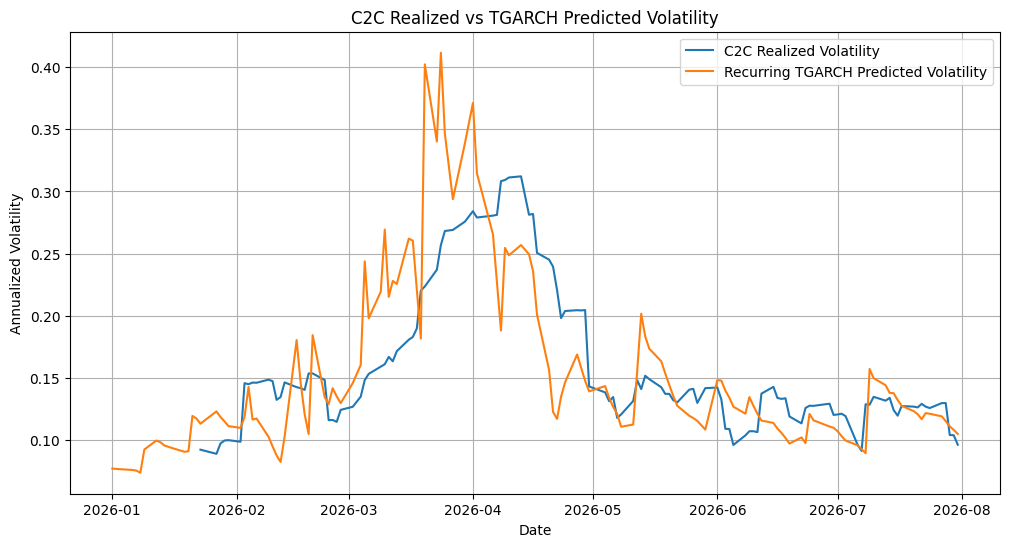

In [168]:
plt.figure(figsize=(12, 6))

plt.plot(test_data.index, test_c2c_vol, label="C2C Realized Volatility")
plt.plot(test_data.index, predicted_vol, label="Recurring TGARCH Predicted Volatility")

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("C2C Realized vs TGARCH Predicted Volatility")

plt.legend()
plt.grid(True)
plt.show()


NOW, what ill do is like get the several n-week volatilities, and then do a recurring linear regression on them to predict the volatilities

In [169]:
def weighted_vol_forecast(days):

    if days <= 30:          # <=6 weeks
        weights = np.array([
            0.50, 0.25, 0.15, 0.05, 0.03, 0.02
        ])

    elif days <= 60:        # 6-12 weeks
        weights = np.array([
            0.35, 0.35, 0.15, 0.07, 0.05, 0.03
        ])

    elif days <= 120:       # 12-24 weeks
        weights = np.array([
            0.20, 0.30, 0.30, 0.10, 0.07, 0.03
        ])

    else:                   # >24 weeks
        weights = np.array([
            0.10, 0.20, 0.25, 0.20, 0.15, 0.10
        ])

    return np.sum(weights * historical_vol)

In [170]:
windows = {
    "6_week_vol": 6 * 5,
    "12_week_vol": 12 * 5,
    "24_week_vol": 24 * 5,
    "30_week_vol": 30 * 5,
    "40_week_vol": 40 * 5,
    "52_week_vol": 52 * 5
}

historical_vol = {}

for name, days in windows.items():

    last_returns = ln_returns.iloc[-days:]

    vol = last_returns.std() * np.sqrt(252)

    historical_vol[name] = vol


historical_vol = np.array(list(historical_vol.values()))

historical_vol = historical_vol.flatten()

In [171]:
predicted_vol1 = []

for day in range(1, len(test_data)+1):
    predicted_vol1.append(
        weighted_vol_forecast(day)
    )

predicted_vol1 = np.array(predicted_vol1)

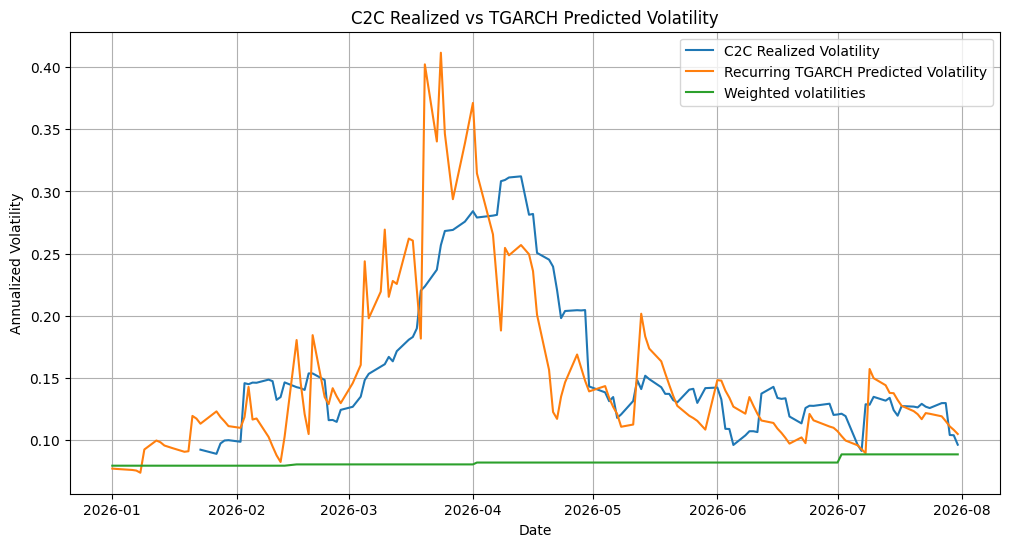

In [172]:
plt.figure(figsize=(12, 6))

plt.plot(test_data.index, test_c2c_vol, label="C2C Realized Volatility")
plt.plot(test_data.index, predicted_vol, label="Recurring TGARCH Predicted Volatility")
plt.plot(test_data.index,predicted_vol1, label = "Weighted volatilities")

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("C2C Realized vs TGARCH Predicted Volatility")

plt.legend()
plt.grid(True)
plt.show()